In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path
import re
import seaborn as sns

# Single

In [296]:
# filt_path = Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-192413/jacobi2d5p_tsc_native_np64_size512_nsampRatio1.0_nsamp142530_filt/')
# filt_path = Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-193938/jacobi2d5p_papi_np64_size512_nsampRatio0.75_nsamp2979_filt/')
# filt_path = Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-193938/jacobi2d5p_tsc_np64_size512_nsampRatio0.75_nsamp1426_filt/')
# filt_path = Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-193938/jacobi2d5p_cgt_np64_size512_nsampRatio0.75_nsamp1581_filt/')    # SUB,C,TF有负数

# filt_path = Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-203055/jacobi2d5p_tsc_np64_size512_nsampRatio0.5_nsamp1147_filt/') # SUB ASM,tf有负数
# filt_path = Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-203055/jacobi2d5p_tsc_np64_size512_nsampRatio0.75_nsamp1457_filt/') # SUB ASM,tf有负数
filt_path = Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-213911/jacobi2d5p_papi_np64_size512_nsampRatio0.75_nsamp3478_filt/') # SUB ASM,tf有负数

tm_hist_path = filt_path / 'tm_hist.csv'
tr_hist_path = filt_path / 'tr_hist.csv'
tf_path = filt_path / 'tf.csv'

In [297]:
!cat $tr_hist_path

441, 0.020956
471, 0.069411
481, 0.117105
491, 0.127089
501, 0.103742
511, 0.075233
521, 0.055275
531, 0.045917
541, 0.042571
551, 0.040363
561, 0.037221
571, 0.033355
581, 0.029631
591, 0.025638
601, 0.022841
611, 0.020217
621, 0.017521
631, 0.015608
641, 0.013985
651, 0.012383
661, 0.010948
671, 0.017598
691, 0.013079
711, 0.013828
741, 0.018483
861, 0.000000


[550 560 561 580 610 611 620 621 630 631 640 641 650 651 660 661 670 671
 680 681 690 691 700 701 710 711 720 721 730 731]


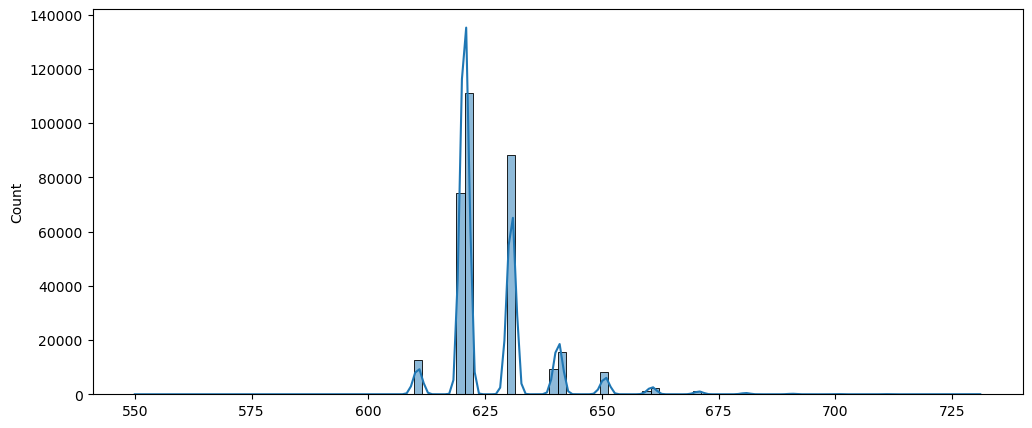

In [299]:
tm_hist_df = pd.read_csv(tm_hist_path, header=None, names=['ns', 'pr'])
tr_hist_df = pd.read_csv(tr_hist_path, header=None, names=['ns', 'pr'])
tf_df = pd.read_csv(tf_path, header=None, names=['ns'])


tf_ns_np = tf_df['ns'].to_numpy()
quantile = np.quantile(tf_ns_np, 0.995)

print(np.unique(tf_ns_np[tf_ns_np <= quantile]))


plt.figure(figsize=(12, 5))
sns.histplot(tf_ns_np[tf_ns_np <= quantile], bins=100, kde=True)
plt.show()

# Statistics

In [84]:
data_root_path = Path('/astrum/home/hpchzy/code/data/20260608/')

# 使用 (?P<date>\d+) 定义命名分组
date_base = re.search(r'/data/(?P<date_base>\d+)/?', str(data_root_path)).groupdict()['date_base']
date_base

'20260608'

{'hostname': 'cgnr6760pn2', 'date_stamp': '20260608-150447', 'kernel': 'jacobi2d5p', 'timer': 'wtime', 'np': '64', 'size': '64'}
(39680,)


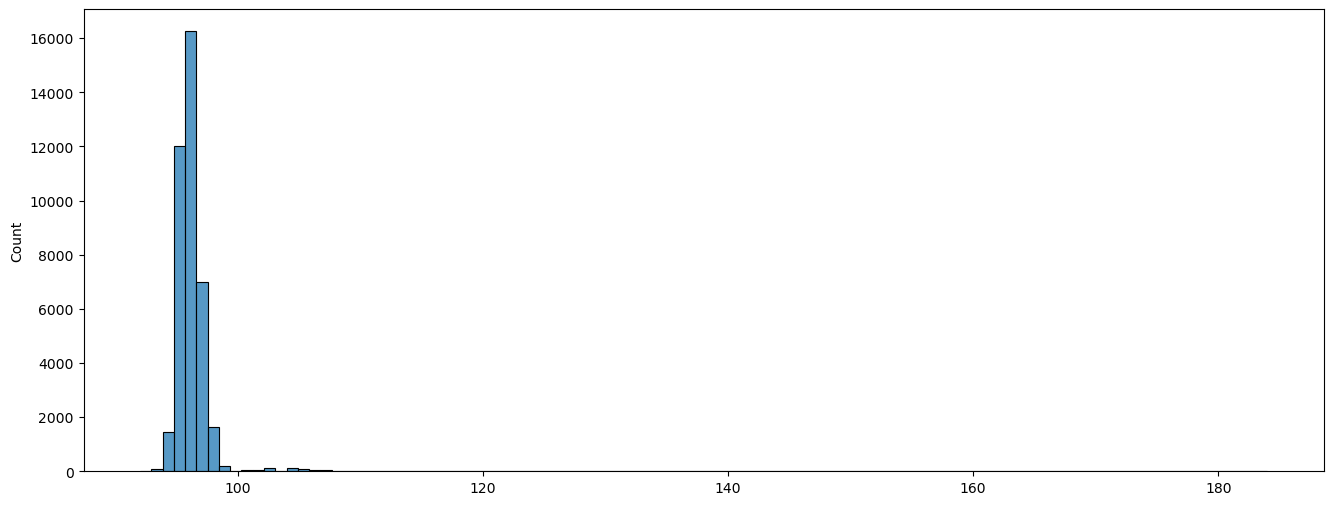

   rank   ns  step     hostname       date_stamp      kernel  timer  np  size
0    54  114     0  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
1    54   96     1  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
2    54   96     2  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
3    54   95     3  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
4    54   95     4  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
               df        sum_sq      mean_sq         F        PR(>F)
C(step)     619.0  8.420782e+05  1360.384761  1.455341  1.393426e-12
C(rank)      63.0  2.091274e+05  3319.482738  3.551187  8.833131e-20
Residual  38997.0  3.645256e+07   934.752975       NaN           NaN


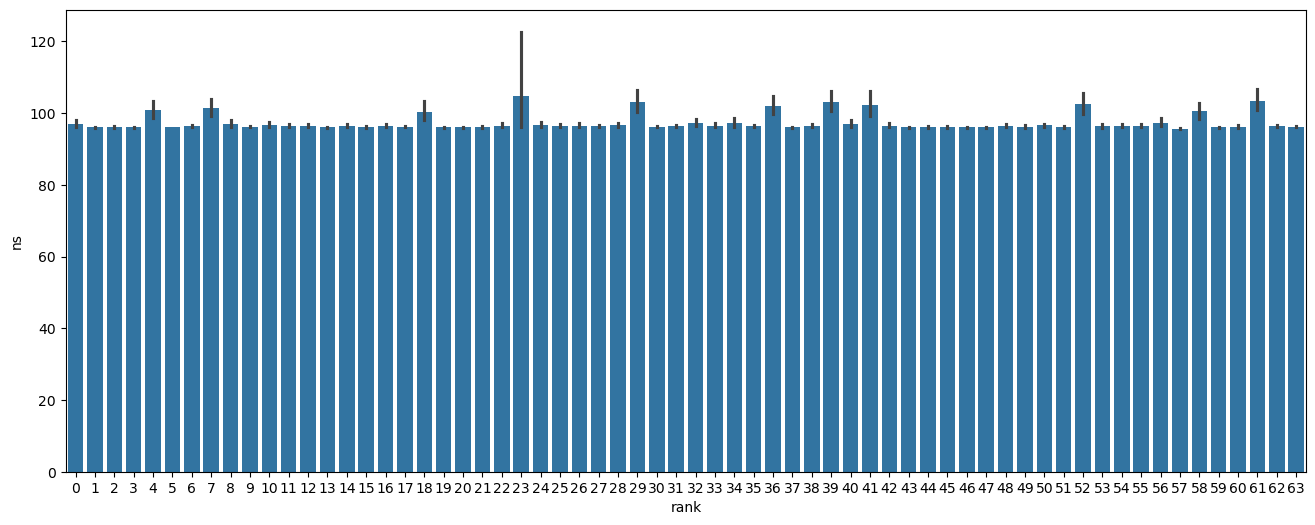

In [209]:

for p in data_root_path.rglob(rf'*size*/'):
    if not re.search(r"size\d+$", p.name):
        continue
    m = re.search(rf'data/{date_base}/(?P<hostname>.*?)/output_filt/(?P<date_stamp>.*?)/(?P<kernel>.*?)_(?P<timer>.*?)_np(?P<np>\d+?)_size(?P<size>\d+)', str(p)).groupdict()
    print(m)

    all_cores_df_list = []
    for csv_file in p.glob("*.csv"):
        rank = re.search(rf'time_(?P<rank>\d+?)_{m["hostname"]}', csv_file.name).groupdict()['rank']
        rank = int(rank)

        # print(csv_file.name)
        df = pd.read_csv(csv_file, header=None, names=['rank', 'ns'])
        df['step'] = df.index
        df['hostname'] = m['hostname']
        df['date_stamp'] = m['date_stamp']
        df['kernel'] = m['kernel']
        df['timer'] = m['timer']
        df['np'] = int(m['np'])
        df['size'] = int(m['size'])

        all_cores_df_list.append(df)

    all_cores_df = pd.concat(all_cores_df_list, ignore_index=True)
    ns_np = all_cores_df['ns'].to_numpy()
    
    print(ns_np.shape)

    q995 = np.quantile(ns_np, 0.995)
    ns_plot = ns_np[ns_np <= q995]
    
    plt.figure(figsize=(16, 6))
    sns.histplot(ns_plot, bins=100, kde=False)
    plt.show()

    all_cores_df = all_cores_df.astype({'rank': 'int32', 'step': 'int32', 'ns': 'int32'})
    print(all_cores_df.head())

    # 回归检验
    import statsmodels.api as sm
    # X = sm.add_constant(all_cores_df['rank'])
    # model = sm.OLS(all_cores_df['ns'], X).fit()
    # print(model.summary()) # 查看斜率系数是否显著，即 ns 是否随 step 变化

    # 方差分析
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    # 建立模型：ns 受 step 和 rank 共同影响
    model = ols('ns ~ C(step) + C(rank)', data=all_cores_df).fit()
    anova_results = anova_lm(model)
    print(anova_results)

    plt.figure(figsize=(16, 6))
    sns.barplot(data=all_cores_df, x='rank', y='ns')
    plt.show()
    break



In [ ]:
for p in data_root_path.rglob('*/tr_hist.csv'):
    print(p.parent)
    print(os.listdir(p.parent))
    m = re.search(rf'data/{date_base}/(?P<hostname>.*?)/output_filt/(?P<date_stamp>.*?)/(?P<kernel>.*?)_(?P<timer>.*?)_np(?P<np>\d+?)_size(?P<size>\d+?)', str(p)).groupdict()
    # m = re.search(f'data/{date_base}/(?P<hostname>.*?)/output_fit/(?P<date_stamp>.*?)/(?P<kernel>.*?)_(?P<timer>.*?)_np(?P<np>\d+?)_size(?P<size>\d+?)[(_filt)|tr]?', str(p)).groupdict() # ERROR
    print(m)
    

/astrum/home/hpchzy/code/data/20260608/cgnr6760pn2/output_filt/20260608-150447/jacobi2d5p_tsc_np64_size64_filt
['tr_hist.csv', 'tf.csv', 'wd.out', 'tm_hist.csv', 'er.out', 'sim_cdf.csv', 'met.csv', 'ep.out']
{'hostname': 'cgnr6760pn2', 'date_stamp': '20260608-150447', 'kernel': 'jacobi2d5p', 'timer': 'tsc', 'np': '64', 'size': '6'}
/astrum/home/hpchzy/code/data/20260608/cgnr6760pn2/output_filt/20260608-150447/jacobi2d5p_papix6_np64_size64_filt
['ep.out', 'sim_cdf.csv', 'met.csv', 'er.out', 'tr_hist.csv', 'wd.out', 'tf.csv', 'tm_hist.csv']
{'hostname': 'cgnr6760pn2', 'date_stamp': '20260608-150447', 'kernel': 'jacobi2d5p', 'timer': 'papix6', 'np': '64', 'size': '6'}
/astrum/home/hpchzy/code/data/20260608/cgnr6760pn2/output_filt/20260608-150447/jacobi2d5p_tsc_native_np64_size64_filt
['er.out', 'tr_hist.csv', 'tf.csv', 'tm_hist.csv', 'wd.out', 'ep.out', 'sim_cdf.csv', 'met.csv']
{'hostname': 'cgnr6760pn2', 'date_stamp': '20260608-150447', 'kernel': 'jacobi2d5p', 'timer': 'tsc_native', 'np